# **Task 1: Multilayer Perceptron (MLP) Classification**

**IMPORTANTE**

Para ter a melhor nota possivel na task 1:

Primeira parte:
- Provides comprehensive statistical summaries and visualizations; quantifies class imbalances with precise percentages.

Segunda parte:
- Designs an MLP with a clear rationale for architecture, activation functions, and regularization techniques; justifies choices based on dataset characteristics.
- Training is well within time budget; optimizes computational resources effectively.

Terceira parte:
- Conducts comprehensive evaluation using multiple metrics; provides in-depth interpretation of results.

## **Data Exploration**

- Assess model performance using appropriate metrics, considering class imbalance.

### Imports

Importante!!!! Trocar de CPU PARA GPU

Tempo de execução -> alterar tipo de tempo de execução -> selecionar T4 GPU e guardar


In [ ]:
#Imports
from google.colab import drive
import sys, os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import random

import pandas as pd

import torch.nn as nn

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

import time
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import shutil

import numpy as np
from PIL import Image
from collections import Counter
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import roc_curve, auc

### Load Dataset and Images

In [ ]:
# Creating the Drive
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/pokemon_dataset'
LOCAL_BASE = '/content/pokemon_dataset'

if not os.path.exists(LOCAL_BASE):
    print("Copying dataset from Drive to local storage...")
    shutil.copytree(DRIVE_BASE, LOCAL_BASE)
    print("Done!")

BASE = LOCAL_BASE

Mounted at /content/drive
Copying dataset from Drive to local storage...
Done!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


In [ ]:
sys.path.append(BASE)
from torchvision import transforms
import CustomImageDataset as CID

train_dataset = CID.CustomImageDataset(
    annotations_file=f'{BASE}/train_labels.csv',
    img_dir=f'{BASE}/Train/',
    transform=transforms.Compose([
        transforms.Lambda(lambda x: x[:3]),
        transforms.ConvertImageDtype(torch.float32),
        transforms.RandomHorizontalFlip(),
        transforms.RandomResizedCrop(64, scale=(0.5, 1.0)),
        transforms.RandomRotation(15),
    ])
)
test_dataset = CID.CustomImageDataset(
    img_dir=f'{BASE}/Test/',
    transform=transforms.Compose([
        transforms.Lambda(lambda x: x[:3]),
        transforms.ConvertImageDtype(torch.float32),
    ])
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'\nTrain: {len(train_dataset)} imagens')
print(f'Test  : {len(test_dataset)} imagens')
print(f'Number of unique classes: {len(train_dataset.classes)}')
print(f'Classes: {train_dataset.classes}')

counts = train_dataset.df['label'].value_counts().sort_index()
total  = len(train_dataset)

class_dist = pd.DataFrame({
    'Label':          counts.index,
    'Count':          counts.values,
    'Percentage(%)':  (counts.values / total * 100).round(2)
}).sort_values(by="Count", ascending=False)

print("Class Distribution Summary:")
print(class_dist.to_string(index=False))

print(f"\nMost common: {counts.idxmax()} ({counts.max()} samples, {(counts.max()/total*100):.2f}%)")
print(f"Least common: {counts.idxmin()} ({counts.min()} samples, {(counts.min()/total*100):.2f}%)")

above_mean = (counts > counts.mean()).sum()
below_mean = (counts < counts.mean()).sum()
print(f"\nClasses above mean count: {above_mean}")
print(f"Classes below mean count: {below_mean}")


Train: 3600 imagens
Test  : 900 imagens
Number of unique classes: 9
Classes: ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']
Class Distribution Summary:
   Label  Count  Percentage(%)
   Water    674          18.72
  Normal    606          16.83
  Poison    467          12.97
    Fire    381          10.58
     Bug    374          10.39
   Grass    299           8.31
Fighting    291           8.08
    Rock    264           7.33
  Ground    244           6.78

Most common: Water (674 samples, 18.72%)
Least common: Ground (244 samples, 6.78%)

Classes above mean count: 3
Classes below mean count: 6


In [ ]:
labels = train_dataset.df['label'].tolist()

train_idx, val_idx = train_test_split(
    range(len(train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(train_dataset, val_idx)

train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=256,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_subset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Treino    : {len(train_subset)} imagens")
print(f"Validação : {len(val_subset)} imagens")

train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
val_labels   = [train_dataset.df.iloc[i]['label'] for i in val_idx]

comparison = pd.DataFrame({
    'Treino':    pd.Series(train_labels).value_counts(normalize=True).round(3) * 100,
    'Validação': pd.Series(val_labels).value_counts(normalize=True).round(3) * 100,
}).sort_values(by='Treino', ascending=False)

print(comparison)

Treino    : 2880 imagens
Validação : 720 imagens
          Treino  Validação
Water       18.7       18.8
Normal      16.8       16.8
Poison      13.0       12.9
Fire        10.6       10.6
Bug         10.4       10.4
Grass        8.3        8.3
Fighting     8.1        8.1
Rock         7.3        7.4
Ground       6.8        6.8


The class distribution of the dataset shows some variation between the number of samples in each class, but the imbalance is not extreme.
- Water is the most frequent class with 674 samples (18.72%).
- Ground is the least frequent class with 244 samples (6.78%).
- The remaining classes have intermediate frequencies, ranging between approximately 7% and 17% of the dataset.


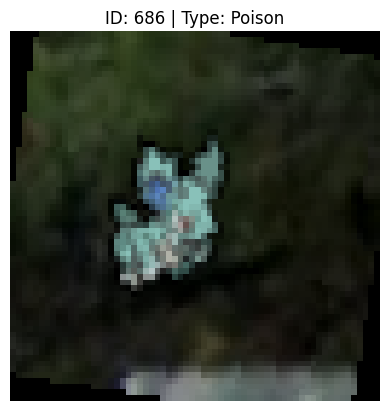

In [ ]:
#Random image from train dataset
idx = random.randint(0, len(train_dataset) - 1)
image, label = train_dataset[idx]

image = image.permute(1, 2, 0)  #Changes the order of dimensions to plt because it's set to pyTorch by default.

plt.imshow(image)
plt.title(f'ID: {idx} | Type: {train_dataset.classes[label]}')
plt.axis('off')
plt.show()

### Obtain information about classes

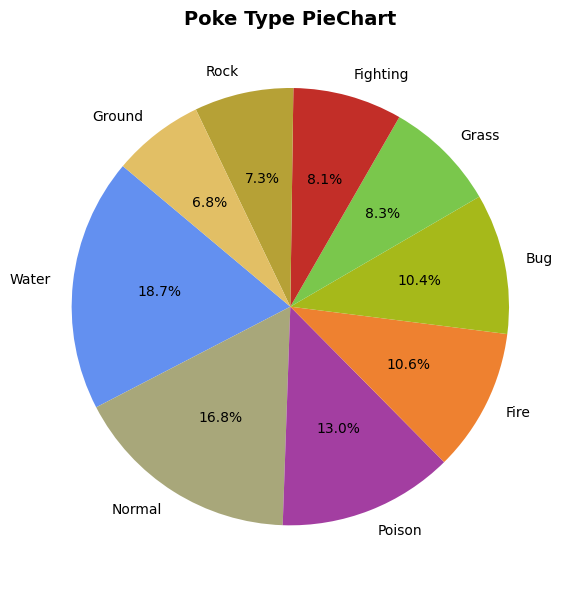

In [ ]:
#Piechart of Pokemon type
type_colors = {
    'Bug':      '#A6B91A',
    'Fighting': '#C22E28',
    'Fire':     '#EE8130',
    'Grass':    '#7AC74C',
    'Ground':   '#E2BF65',
    'Normal':   '#A8A77A',
    'Poison':   '#A33EA1',
    'Rock':     '#B6A136',
    'Water':    '#6390F0',
}

labels  = class_dist['Label'].tolist()
counts  = class_dist['Count'].tolist()
colors  = [type_colors.get(l, '#888888') for l in labels]  #Grey if the type doesn´t exist

plt.figure(figsize=(8, 6))
plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Poke Type PieChart', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Imbalance ratio
counts = np.array(class_dist['Count'].tolist())

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

class_probs = counts / total
entropy_value = entropy(class_probs)
normalized_entropy = entropy_value / np.log(len(counts))
print(f"Entropy: {normalized_entropy:.4f}")

# Gini (0 to 0.8889)
gini = 1 - np.sum(class_probs ** 2)
print(f"Gini Index: {gini:.4f}")

Imbalance Ratio (Max/Min): 2.76
Entropy: 0.9719
Gini Index: 0.8744


The Imbalance Ratio (Max/Min) is 2.76, meaning that the most frequent class (Water) appears 2.76 times more often than the least frequent class (Ground).
This indicates a moderate level of class imbalance, but not severe enough to dominate the dataset.

The entropy value is 0.9719 (which is very close to 1). High entropy indicates that the class distribution is relatively balanced, meaning that no single class overwhelmingly dominates the dataset.

The Gini Index is 0.8744, which is also relatively high. A high Gini value suggests that the probability of randomly selecting two samples from different classes is high, further confirming that the dataset maintains good diversity among classes.

### Obtain information about the images

In [ ]:
# Obtain information about the columns
print(train_dataset.df.columns)
print(train_dataset.df.head())

Index(['Id', 'label'], dtype='object')
                                     Id   label
0  6fc9045b-9983-41e2-be2d-8796ecd97412  Normal
1  874716ce-9048-4e8a-b980-5ed9a5c0110e  Poison
2  c3613b20-ead8-48e1-8c8d-2f219d8e19d4  Normal
3  c7264ebc-ba44-460a-9b2b-df23c04783bc  Normal
4  a72045db-8fae-458b-993e-23d2aab1a5c6  Normal


In [ ]:
def compute_mean_std(dataset):
    means, stds = [], []
    for img_id in dataset.df['Id']:
        path = f'{BASE}/Train/{img_id}.png'
        if os.path.exists(path):
            img = np.array(Image.open(path).convert('RGB')) / 255.0
            means.append(img.mean(axis=(0,1)))
            stds.append(img.std(axis=(0,1)))
    means = np.array(means).mean(axis=0)
    stds  = np.array(stds).mean(axis=0)
    print(f"Mean (R, G, B): {means.round(4)}")
    print(f"Std  (R, G, B): {stds.round(4)}")

compute_mean_std(train_dataset)

Mean (R, G, B): [0.4433 0.4455 0.4135]
Std  (R, G, B): [0.1819 0.1725 0.1814]


These values indicate that the overall color distribution of the dataset is relatively balanced across the three channels. The Red and Green channels have slightly higher average values than the Blue channel, suggesting a small tendency toward warmer colors in the images. The standard deviation values are also similar across channels, indicating that the variability of pixel intensities is fairly consistent.


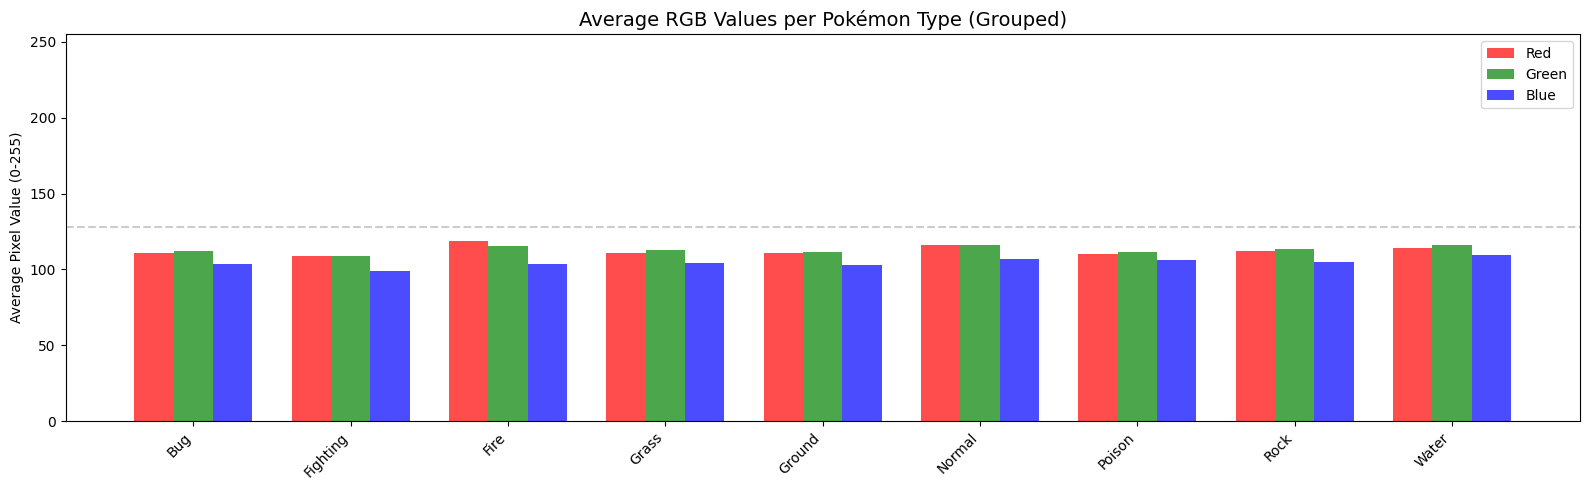

In [ ]:
def avg_color_per_type(dataset):
    type_colors = {}
    for ptype in dataset.df['label'].unique():
        subset = dataset.df[dataset.df['label'] == ptype]
        rgbs = [np.array(Image.open(f'{BASE}/Train/{img_id}.png').convert('RGB')).mean(axis=(0,1))
                for img_id in subset['Id'] if os.path.exists(f'{BASE}/Train/{img_id}.png')]
        if rgbs:
            type_colors[ptype] = np.array(rgbs).mean(axis=0)

    types  = sorted(type_colors.keys())
    r_vals = [type_colors[t][0] for t in types]
    g_vals = [type_colors[t][1] for t in types]
    b_vals = [type_colors[t][2] for t in types]

    x = np.arange(len(types))
    width = 0.25
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(x - width, r_vals, width, color='red',   alpha=0.7, label='Red')
    ax.bar(x,         g_vals, width, color='green', alpha=0.7, label='Green')
    ax.bar(x + width, b_vals, width, color='blue',  alpha=0.7, label='Blue')
    ax.set_xticks(x)
    ax.set_xticklabels(types, rotation=45, ha='right')
    ax.set_title('Average RGB Values per Pokémon Type (Grouped)', fontsize=14)
    ax.set_ylabel('Average Pixel Value (0-255)')
    ax.legend()
    ax.set_ylim(0, 255)
    ax.axhline(128, color='gray', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

avg_color_per_type(train_dataset)

These observations are consistent with what was previously seen in the average color per type analysis. We can identify very small tendencies, such as the Red channel being slightly more prominent in the Fire type compared to the Blue channel.

However, these color patterns are not strong enough to draw significant conclusions about the classes based solely on RGB statistics. This is most likely due to the backgrounds present in the images, which introduce additional colors that are unrelated to the Pokémon itself.

In [ ]:
# Missing values
missing = [img_id for img_id in train_dataset.df['Id']
           if not os.path.exists(f'{BASE}/Train/{img_id}.png')]
print(f"Imagens em falta: {len(missing)}")

# Duplicates
print(f"IDs duplicados: {train_dataset.df['Id'].duplicated().sum()}")

# Resolutions
sizes = Counter(Image.open(f'{BASE}/Train/{img_id}.png').size
                for img_id in train_dataset.df['Id']
                if os.path.exists(f'{BASE}/Train/{img_id}.png'))
print(f"Resoluções distintas: {len(sizes)} → {dict(sizes)}")

Imagens em falta: 0
IDs duplicados: 0
Resoluções distintas: 1 → {(64, 64): 3600}


No duplicate IDs exist, so each image is unique.
All images share the same resolution (64×64 pixels), which means no resizing is necessary before processing.


##Model Development


###Submition





In [ ]:
train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
val_labels   = [train_dataset.df.iloc[i]['label'] for i in val_idx]

comparison = pd.DataFrame({
    'Treino':    pd.Series(train_labels).value_counts(normalize=True).round(3) * 100,
    'Validação': pd.Series(val_labels).value_counts(normalize=True).round(3) * 100,
}).sort_values(by='Treino', ascending=False)

print(comparison)

          Treino  Validação
Water       18.7       18.8
Normal      16.8       16.8
Poison      13.0       12.9
Fire        10.6       10.6
Bug         10.4       10.4
Grass        8.3        8.3
Fighting     8.1        8.1
Rock         7.3        7.4
Ground       6.8        6.8


In [ ]:
train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
train_series = pd.Series(train_labels)
class_counts = train_series.value_counts()

total = len(train_labels)
weights_list = []

for pokeType in train_dataset.classes:
    weight = (total / class_counts[pokeType]) ** 0.5
    weights_list.append(weight)


class_weights = torch.tensor(weights_list, dtype=torch.float32).to(device)

print("Class Weights:")
for cls, w in zip(train_dataset.classes, class_weights):
    print(f"  {cls:<12} count: {class_counts[cls]:>4}  weight: {w:.3f}")

Class Weights:
  Bug          count:  299  weight: 3.104
  Fighting     count:  233  weight: 3.516
  Fire         count:  305  weight: 3.073
  Grass        count:  239  weight: 3.471
  Ground       count:  195  weight: 3.843
  Normal       count:  485  weight: 2.437
  Poison       count:  374  weight: 2.775
  Rock         count:  211  weight: 3.694
  Water        count:  539  weight: 2.312


In [ ]:
class PokemonMLP(nn.Module):
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(

            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.4),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.3),

            nn.Linear(64, num_classes)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='leaky_relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [ ]:
sample_image, _ = train_dataset[0]
INPUT_SIZE = sample_image.numel()

NUM_CLASSES = len(train_dataset.classes)
model = PokemonMLP(INPUT_SIZE, NUM_CLASSES).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)

In [ ]:
EPOCHS        = 100
PATIENCE      = 15 # Early Stoping
CHECKPOINT = f"{BASE}/best_mlp_pokemon.pt"

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

total_start = time.time()

In [ ]:
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Train
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    train_loss = running_loss / len(train_dataset)

    # Validate
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
    val_loss /= len(val_subset)
    val_acc   = correct / len(val_subset)

    scheduler.step(val_loss)

    # Timing + GPU
    epoch_time = time.time() - epoch_start
    gpu_mem = (torch.cuda.memory_allocated(device) / 1e6
               if device.type == "cuda" else 0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch:>3}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Val Acc: {val_acc:.2%}  "
          f"Time: {epoch_time:.1f}s  "
          f"GPU: {gpu_mem:.0f}MB")

    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f"Checkpoint saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)")

In [ ]:
# Evaluation — load best checkpoint

model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\n── Classification Report ──────────────────────────────────────")
print(classification_report(all_labels, all_preds,
                             target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix — Pokémon Type MLP")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss"); plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


####Kaggle Submition


In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu()

        for id_, pred in zip(ids, preds):
            predictions.append({
                'Id': id_,
                'label': train_dataset.classes[pred.item()]
            })

# Create submission CSV
submission_df = pd.DataFrame(predictions)
submission_df = submission_df.sort_values('Id')
submission_df.to_csv(f'{BASE}/submission.csv', index=False)

print(submission_df.head(10))
print(f"\nTotal predictions: {len(submission_df)}")

                                     Id   label
0  003535c4-fa59-4648-b231-30dc139665ed  Normal
1  004a13ae-e627-4df9-8ad0-297449af3b22     Bug
2  00b78c26-7b4f-4582-bbb1-5a1c03f5709e  Normal
3  00bbc4e6-5eb3-4914-b3b6-aeb22349a825   Grass
4  00c3c5a5-e49c-453c-ad53-79cd72c6f896  Normal
5  01540c75-52a9-49ec-960c-8341d09ee294  Normal
6  01b0900d-6ee5-4609-9da9-5ca4765d7be2     Bug
7  01ce5264-37cb-4f47-8da3-23528dcfa90f    Fire
8  027773c9-744b-4498-bcf2-83ab8fc0b227    Fire
9  02a846af-f6ca-4896-92a2-486cc34cd435     Bug

Total predictions: 900


###Model Testing




In [ ]:
train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
train_series = pd.Series(train_labels)
class_counts = train_series.value_counts()

total = len(train_labels)
weights_list = []

for pokeType in train_dataset.classes:
    weight = (total / class_counts[pokeType]) ** 0.5
    weights_list.append(weight)


class_weights = torch.tensor(weights_list, dtype=torch.float32).to(device)

print("Class Weights:")
for cls, w in zip(train_dataset.classes, class_weights):
    print(f"  {cls:<12} count: {class_counts[cls]:>4}  weight: {w:.3f}")

Class Weights:
  Bug          count:  299  weight: 3.104
  Fighting     count:  233  weight: 3.516
  Fire         count:  305  weight: 3.073
  Grass        count:  239  weight: 3.471
  Ground       count:  195  weight: 3.843
  Normal       count:  485  weight: 2.437
  Poison       count:  374  weight: 2.775
  Rock         count:  211  weight: 3.694
  Water        count:  539  weight: 2.312


In [ ]:
class PokemonMLP(nn.Module):
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(

            nn.Linear(input_size, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),

            nn.Linear(1024, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.2),

            nn.Linear(64, num_classes)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, mode='fan_in', nonlinearity='leaky_relu')
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

In [ ]:
sample_image, _ = train_dataset[0]
INPUT_SIZE = sample_image.numel()

NUM_CLASSES = len(train_dataset.classes)
model = PokemonMLP(INPUT_SIZE, NUM_CLASSES).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7)

In [ ]:
EPOCHS        = 100
PATIENCE      = 15 # Early Stoping
CHECKPOINT = f"{BASE}/best_mlp_pokemon.pt"

best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

total_start = time.time()

In [ ]:
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Train
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    train_loss = running_loss / len(train_dataset)

    # Validate
    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
    val_loss /= len(val_subset)
    val_acc   = correct / len(val_subset)

    scheduler.step(val_loss)

    # ── Timing + GPU ──────────────────────────────────────────────────────────
    epoch_time = time.time() - epoch_start
    gpu_mem = (torch.cuda.memory_allocated(device) / 1e6
               if device.type == "cuda" else 0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch [{epoch:>3}/{EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Val Acc: {val_acc:.2%}  "
          f"Time: {epoch_time:.1f}s  "
          f"GPU: {gpu_mem:.0f}MB")

    # ── Checkpointing ─────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CHECKPOINT)
        print(f"Checkpoint saved (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)")

Epoch [  1/100]  Train Loss: 1.9982  Val Loss: 2.5249  Val Acc: 15.28%  Time: 6.0s  GPU: 234MB
Checkpoint saved (val_loss=2.5249)
Epoch [  2/100]  Train Loss: 1.9401  Val Loss: 2.2330  Val Acc: 15.00%  Time: 7.0s  GPU: 234MB
Checkpoint saved (val_loss=2.2330)
Epoch [  3/100]  Train Loss: 1.8829  Val Loss: 2.2018  Val Acc: 15.83%  Time: 5.6s  GPU: 234MB
Checkpoint saved (val_loss=2.2018)
Epoch [  4/100]  Train Loss: 1.8792  Val Loss: 2.1842  Val Acc: 19.86%  Time: 7.3s  GPU: 234MB
Checkpoint saved (val_loss=2.1842)
Epoch [  5/100]  Train Loss: 1.8416  Val Loss: 2.1580  Val Acc: 17.22%  Time: 5.6s  GPU: 234MB
Checkpoint saved (val_loss=2.1580)
Epoch [  6/100]  Train Loss: 1.8296  Val Loss: 2.1409  Val Acc: 20.56%  Time: 6.6s  GPU: 234MB
Checkpoint saved (val_loss=2.1409)
Epoch [  7/100]  Train Loss: 1.8143  Val Loss: 2.1411  Val Acc: 18.47%  Time: 5.9s  GPU: 234MB
Epoch [  8/100]  Train Loss: 1.7930  Val Loss: 2.1524  Val Acc: 18.75%  Time: 5.4s  GPU: 234MB
Epoch [  9/100]  Train Loss: 1


── Classification Report ──────────────────────────────────────
              precision    recall  f1-score   support

         Bug       0.14      0.12      0.13        75
    Fighting       0.25      0.09      0.13        58
        Fire       0.36      0.58      0.45        76
       Grass       0.30      0.18      0.23        60
      Ground       0.23      0.06      0.10        49
      Normal       0.18      0.27      0.22       121
      Poison       0.34      0.42      0.38        93
        Rock       0.14      0.08      0.10        53
       Water       0.44      0.45      0.45       135

    accuracy                           0.29       720
   macro avg       0.26      0.25      0.24       720
weighted avg       0.28      0.29      0.27       720



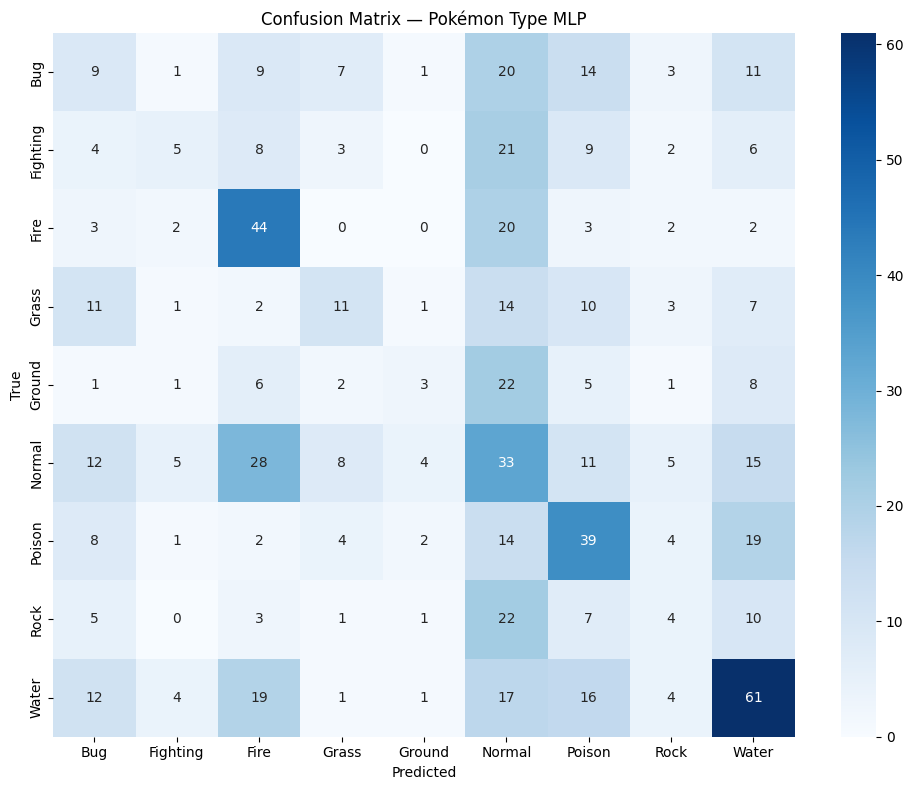

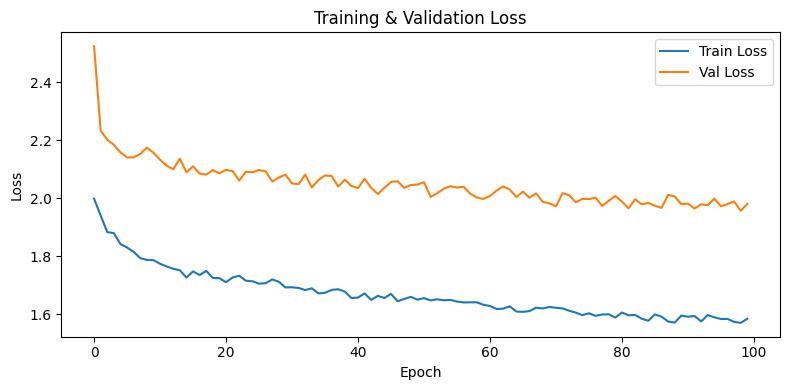

In [ ]:
# Evaluation — load best checkpoint

model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds  = model(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\n── Classification Report ──────────────────────────────────────")
print(classification_report(all_labels, all_preds,
                             target_names=train_dataset.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix — Pokémon Type MLP")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss"); plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()


####Kaggle Submition


In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load(CHECKPOINT))
model.eval()

predictions = []

with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(1).cpu()

        for id_, pred in zip(ids, preds):
            predictions.append({
                'Id': id_,
                'label': train_dataset.classes[pred.item()]
            })

# Create submission CSV
submission_df = pd.DataFrame(predictions)
submission_df = submission_df.sort_values('Id')
submission_df.to_csv(f'{BASE}/submission.csv', index=False)

print(submission_df.head(10))
print(f"\nTotal predictions: {len(submission_df)}")

                                     Id   label
0  003535c4-fa59-4648-b231-30dc139665ed    Fire
1  004a13ae-e627-4df9-8ad0-297449af3b22     Bug
2  00b78c26-7b4f-4582-bbb1-5a1c03f5709e  Normal
3  00bbc4e6-5eb3-4914-b3b6-aeb22349a825  Normal
4  00c3c5a5-e49c-453c-ad53-79cd72c6f896  Normal
5  01540c75-52a9-49ec-960c-8341d09ee294  Poison
6  01b0900d-6ee5-4609-9da9-5ca4765d7be2     Bug
7  01ce5264-37cb-4f47-8da3-23528dcfa90f    Fire
8  027773c9-744b-4498-bcf2-83ab8fc0b227  Normal
9  02a846af-f6ca-4896-92a2-486cc34cd435   Grass

Total predictions: 900
